# L18 Parameter Inference & Bootstrapping

## 1 Bootstrapping Resampling (重采样)

- Usually we **only get one sample** (like a round of survey), how can we know what will happen if we resampling?

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **e.g.**

Say we want to estimate the average height $\mu$ for all students (population)

- We first sample 100 people, compute $\bar{X}=\frac{1}{100} \sum_{i=1}^{100} X_i$

But you know if you resample again, you will get another number

Ideally we can resample multiple times to get multiple $\bar{X}_i$

- The distribution of $\bar{X}$ is **sampling distribution (抽样分布)**

	- So we can get $Var(\bar{X})$ & $SE(\bar{X})$ & Confidence Interval

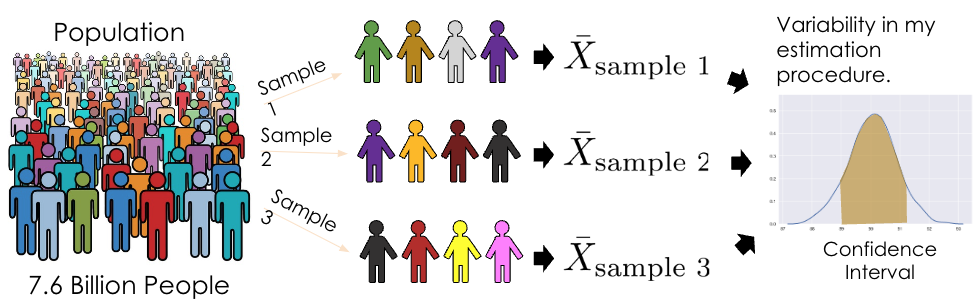

**But usually you cannot go back and resample: you only get one sample!**

- The solution is, we **treat this 100-person sample as a small population**

    - We can resample 100 people from this 100-person population **WITH placement** (So one people can show up many times)

	- **New samples must be the same size as the original sample** so it matches the variability of our estimates

- We can get the **bootstrap distribution**

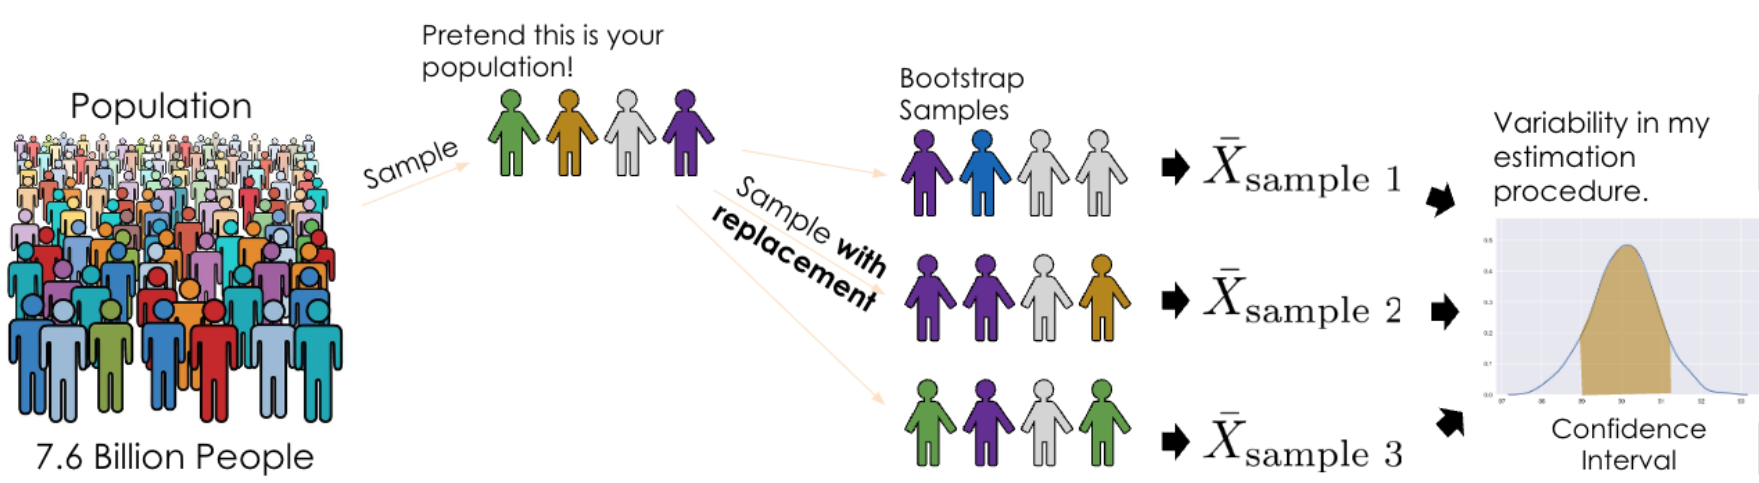
</div>

- Is it good enough? Workable

- It is usually used to **measure how volatile our estimate can be**

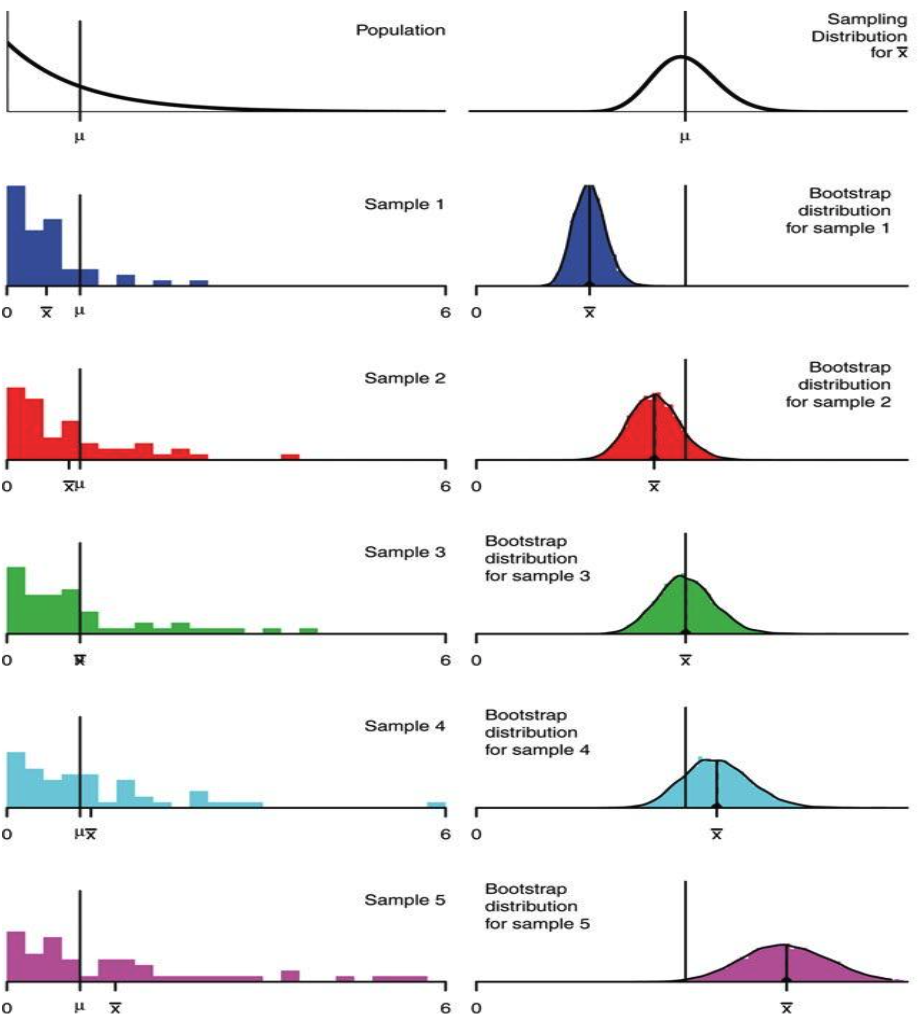

**Limitation**

- When increasing the times of bootstrap, we get closer to the sample estimate rather than the real mean of population (Since we are just resample from the sample)

- Bootstrap cannot solve sampling bias

### e.g. Bootstrapping a Regression Coefficient

- Try to estimate the relationship between miles per gallon and the weight of a vehicle

$$\widehat{\mathrm{mpg}} = \hat{\theta}_0 + \hat{\theta}_1 * \mathrm{weight}$$

- Suppose we collected a **sample of 20 cars** from a population
  
- For the purposes of this demo, we will assume that the **seaborn’s mpg dataset represents the entire population**

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import sklearn.linear_model as lm
import seaborn as sns

np.random.seed(42)
sample_size = 100
mpg = sns.load_dataset('mpg')
print("Full Data Size:", len(mpg))
mpg_sample = mpg.sample(sample_size)
print("Sample Size:", len(mpg_sample))
px.scatter(mpg_sample, x='weight', y='mpg', trendline='ols', width=800)

Full Data Size: 398
Sample Size: 100


- fitting a linear model and get estimate of the slope $\hat{\theta}_1$

In [2]:
model = lm.LinearRegression().fit(mpg_sample[['weight']], mpg_sample['mpg'])
model.coef_[0] 

np.float64(-0.007305965155512159)

**Bootstrap Implementation**

- We can use bootstrapping to **estimate the distribution of that coefficient**

In [ ]:
def estimator(sample):
    """
    Fits an SLR to `sample` regressing mpg on weight, 
    and returns the slope of the fitted line
    """
    
    model = lm.LinearRegression().fit(sample[['weight']], sample['mpg'])
    return model.coef_[0]

In [4]:
# Generate a bootstrap sample that is the same size as the original sample

def bootstrap(sample, statistic, num_repetitions):
    """
    Returns the statistic computed on a num_repetitions  
    bootstrap samples from sample.
    """
    stats = []
    for i in np.arange(num_repetitions):
        # Step 1: Resample with replacement from our original sample to generate
        # a synthetic sample of the same size
        bootstrap_sample = sample.sample(frac=1, replace=True)
        
        # Step 2: Calculate a synthetic estimate using the synthetic sample
        bootstrap_stat = statistic(bootstrap_sample)
        
        # Append the synthetic estimate to the list of estimates
        stats.append(bootstrap_stat)
    return stats  

In [5]:
#Construct 10,000 bootstrap slope estimates
bs_thetas = bootstrap(mpg_sample, estimator, 10000)

#Visualize the distribution of these estimates
px.histogram(bs_thetas, title='Bootstrap Distribution of the Slope', 
             width=800)

**Computing CI**

- We are looking for a 95% confidence interval, so we want values at the 2.5 and 97.5 percentiles of the bootstrap samples to be the bounds of our interval

In [7]:
def bootstrap_ci(bootstrap_samples, confidence_level=95):
    """
    Returns the confidence interval for the bootstrap samples.
    """
    lower_percentile = (100 - confidence_level) / 2
    upper_percentile = 100 - lower_percentile
    return np.percentile(bootstrap_samples, [lower_percentile, upper_percentile])

print(bootstrap_ci(bs_thetas))

[-0.00814752 -0.00653232]


**Comparing to the Population CIs**

In [8]:
mpg_pop = sns.load_dataset('mpg')
theta_est = [estimator(mpg_pop.sample(20)) for i in range(10000)]
print(bootstrap_ci(theta_est))

[-0.01019291 -0.00573015]


In [9]:
thetas = pd.DataFrame({"bs_thetas": bs_thetas, "thetas": theta_est})
px.histogram(thetas.melt(), x='value', facet_row='variable', 
             title='Distribution of the Slope', width=800)

- Although our bootstrapped sample distribution does not exactly match the sampling distribution of the population, we can see that it is relatively close

## 2 Prediction & Inference

**Prediction**

- Using our model to make accurate predictions about unseen data

- Goal: get $\hat{Y}$ close to $Y$

**Inference**

- Using our model to study underlying relationships between our features and response

- Goal: How and why does $X$ relate to $Y$

- Inference is closely associated with both correlation and causality

**Correlational inference**

- Are homes with granite countertops worth more money?

**Causal inference** (harder!)

- Does getting a college degree *increase* lifetime earnings?

- Does smoking *cause* cancer?

Questions about **causality** are about the **effects of interventions** (not just passive observation)

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> 

When using data alone, **predictive questions** can be answered, but **causal questions** cannot

- **Causal effect**: breastfeeding makes babies healthier

- **Reverse causality**: healthier babies more likely to successfully breastfeed

- **Common cause**: healthier / richer parents have healthier babies and are more likely to breastfeed

We cannot tell which explanations are true (or to what extent) just by observing $(x, y)$ pairs

- Additionally, causal questions implicitly involve **counterfactuals**, events that didn’t happen

</div>

## 3 Regression Inference

### Correlational Inference

- Let's apply those to a regression task

- Suppose we have a dataset of lifetime earnings and college degree status

- The relation can be written as:

$$\widehat{\mathrm{Earnings}}
=
\hat{\theta}_0
+
\hat{\theta}_1(\mathrm{Has\ college\ degree})$$

- Intercept: What are the predicted lifetime earnings for someone **without** a college degree?

- Slope: How much higher are predicted earnings for someone **with** a degree, relative to someone without a degree?

- Say it turns out that $\hat{\theta_1} >> 0$

- Can we say getting a college degree increases lifetime earnings?

	**NO!**

- People with college degrees may just be more likely to have other traits that increase lifetime earnings, like family wealth **(Confounders)**

- There could be other **observed** confounders, like health, demographics, and geography

- There could also be **unobserved** confounders, like intrinsic motivation and values. We cannot be certain we’ve isolated the causal effect!

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **Confounding Factors**

- T represent a treatment (for example, alcohol use)

- Y represent an outcome (for example, lung cancer)

- A **confounder** is a variable that affects both T and Y, distorting the correlation between them

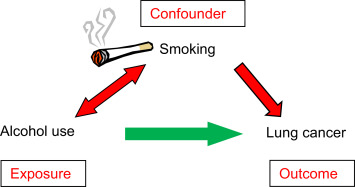

- We commonly assume that all confounders are observed and adjusted for (this is also called **ignorability**)

</div>

### Causal Inference

- Correlation does not imply causation does not mean that OLS is useless for exploring causation

- Anthropic ran a randomized experiment on **whether CS students who did or did not use AI got higher or lower quiz scores**

$$\widehat{\mathrm{Quiz\ score}}
=
\hat{\theta}_0
+
\hat{\theta}_1(\mathrm{Used\ AI})$$

- $\hat{\theta}_0$: The average quiz score when students **did not use AI**

- $\hat{\theta}_1$: The predicted change in quiz score when students **use AI**

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- The key difference in this study is that researchers conducted a **randomized controlled trial (RCT)**
  
  - Each participant was randomly assigned into groups that either used AI or did not use AI (不是你原先用不用AI来分，而是你来了随机分组我来决定允不允许你用AI)

- Because the treatment (Used AI) was randomly assigned, it is independent of other factors that affect quiz scores

- Therefore, the OLS estimate $\hat{\theta}_1$ can be interpreted as the causal effect of AI usage on quiz scores

- If a hypothesis test rejects the null hypothesis that $\hat{\theta}_1=0$, this provides evidence that AI usage had a causal effect on quiz scores

**The key is RCT!**
</div>

## 4 Collinearity

- Adding new terms to a regularized model often improves predictive performance

- So we can add as many as possible?

	**NO!**

$$\widehat{\mathrm{Earnings}}
=
\hat{\theta}_0
+
\hat{\theta}_1(\mathrm{Has\ college\ degree})
+
\hat{\theta}_2(\mathrm{Family\ wealth\ in\ dollars})
+
\hat{\theta}_3(\mathrm{Has\ lived\ in\ a\ college\ town})$$

- Having a college degree and living in a college town are very **highly correlated features**. To the regression model, these **features look very similar**!

- The regression model does not know that a college degree is more likely to change earnings than living in a college town. This is causal domain knowledge

- **It doesn't affect prediction power, but it will confound the inference and the validity of $\hat{\theta_1}$**

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- If you want to make inferences about a parameter, **don’t include features that are highly correlated with that parameter’s feature**

</div>

## 5 *Causal Inference & Hypothesis Testing

- Bonus Content so omitted

---
[Reference](https://ds100.org/course-notes/inference-causality/)